<a href="https://colab.research.google.com/github/LarshVakil/Pokemon-Classification-and-Regression/blob/main/PokemonClassificationRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

#Importing from kagglehub rather than downloading csv and putting in files
import kagglehub
import os
path = kagglehub.dataset_download("abcsds/pokemon")

Using Colab cache for faster access to the 'pokemon' dataset.


In [8]:
#Loaded dataset
csv_path = os.path.join(path, "Pokemon.csv")
df = pd.read_csv(csv_path)
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [9]:
#EDA

print(df.shape)


print(df.describe())

# We see even though 800 enteries only 721 indexes because Charizard , mega charizard X , mega chrizard Y all 3 have index 6
print(df.isnull().sum())

# 386 pokemon are not dual types so second type , type 2 is NaN lets use fillna to clean it

df['Type 2'] = df['Type 2'].fillna('None')

#test
#print(df.isnull().sum())

#Checking is all pokrmon BST adds up

count = 0
for i in range(len(df)):
  if df.loc[i, 'Total'] == df.loc[i, 'HP'] + df.loc[i, 'Attack'] + df.loc[i, 'Defense'] + df.loc[i, 'Sp. Atk'] + df.loc[i, 'Sp. Def'] + df.loc[i, 'Speed']:
    pass
  else:
    count+=1
print(count)

#Checking total legy

total_legy = df['Legendary'].sum()

print(total_legy)



(800, 13)
                #      Total          HP      Attack     Defense     Sp. Atk  \
count  800.000000  800.00000  800.000000  800.000000  800.000000  800.000000   
mean   362.813750  435.10250   69.258750   79.001250   73.842500   72.820000   
std    208.343798  119.96304   25.534669   32.457366   31.183501   32.722294   
min      1.000000  180.00000    1.000000    5.000000    5.000000   10.000000   
25%    184.750000  330.00000   50.000000   55.000000   50.000000   49.750000   
50%    364.500000  450.00000   65.000000   75.000000   70.000000   65.000000   
75%    539.250000  515.00000   80.000000  100.000000   90.000000   95.000000   
max    721.000000  780.00000  255.000000  190.000000  230.000000  194.000000   

          Sp. Def       Speed  Generation  
count  800.000000  800.000000   800.00000  
mean    71.902500   68.277500     3.32375  
std     27.828916   29.060474     1.66129  
min     20.000000    5.000000     1.00000  
25%     50.000000   45.000000     2.00000  
50%  

In [10]:
# Feature encoding (One Hot)

ohe = OneHotEncoder(handle_unknown='ignore',sparse_output= False).set_output(transform='pandas')
df2 = ohe.fit_transform(df[['Legendary','Type 1','Type 2','Generation']])
df2.head()

df = pd.concat([df,df2],axis=1).drop(['Legendary','Type 1','Type 2'],axis=1)
df.head()

,#,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,...,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water,Generation_1,Generation_2,Generation_3,Generation_4,Generation_5,Generation_6
0,1,Bulbasaur,318,45,49,49,65,65,45,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,Ivysaur,405,60,62,63,80,80,60,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,Venusaur,525,80,82,83,100,100,80,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,VenusaurMega Venusaur,625,80,100,123,122,120,80,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,4,Charmander,309,39,52,43,60,50,65,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [11]:
#Testing , Training with random forest regressor


#---------------------Regression Task ------------------------------------------
#Split into X AND y


# Adding total decreases the mse and r2 but have dropped it intentionally
X = df.drop(columns=['#', 'Name', 'HP','Total'])
y = df['HP']

# Train test split 80 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

pipe = Pipeline([
    ('model', RandomForestRegressor())
])


#Training
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

#Accuracy metrics as mentioned (Mean Squared Error (MSE) and R-Squared metrics, respectively)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'mse: {mse}')
print(f'r2: {r2}')

Training Data Shape: (640, 51)
Testing Data Shape: (160, 51)
mse: 219.54887875
r2: 0.47133155939493965


In [14]:
#Classificaiton of legendary pokemon

#Reading the theory I assume the best model will be decision trees as it asks questions whether the total is above 580 or not and
#a higher total is almost guaranteed a legendary

#I Have one hot encoded legendary ehich i need to remove

X = df.drop(columns=['Legendary_True', 'Legendary_False' ,'Name', 'Generation', '#'])

y = df['Legendary_True']

# Train test split 80 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

pipe_lr = Pipeline([
    ('model', LogisticRegression(solver='liblinear', random_state=1))
])

pipe_svm = Pipeline([
    ('model', SVC(random_state=1))
])

pipe_lda = Pipeline([
    ('model', LinearDiscriminantAnalysis())
])

pipe_dt = Pipeline([
    ('model', DecisionTreeClassifier(random_state=1))
])

pipe_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=1))
])


pipe_lr.fit(X_train, y_train)
pipe_svm.fit(X_train, y_train)
pipe_lda.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)


y_pred_lr = pipe_lr.predict(X_test)
y_pred_svm = pipe_svm.predict(X_test)
y_pred_lda = pipe_lda.predict(X_test)
y_pred_dt = pipe_dt.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_lda = accuracy_score(y_test, y_pred_lda)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f'Logistic Regression Accuracy: {accuracy_lr}')
print(f'SVM Accuracy: {accuracy_svm}')
print(f'LDA Accuracy: {accuracy_lda}')
print(f'Decision Tree Accuracy: {accuracy_dt}')
print(f'Random Forest Accuracy: {accuracy_rf}')


precision_lr = precision_score(y_test, y_pred_lr)
precision_svm = precision_score(y_test, y_pred_svm)
precision_lda = precision_score(y_test, y_pred_lda)
precision_dt = precision_score(y_test, y_pred_dt)
precision_rf = precision_score(y_test, y_pred_rf)

print(f'Logistic Regression Precision: {precision_lr}')
print(f'SVM Precision: {precision_svm}')
print(f'LDA Precision: {precision_lda}')
print(f'Decision Tree Precision: {precision_dt}')
print(f'Random Forest Precision: {precision_rf}')

recall_lr = recall_score(y_test, y_pred_lr)
recall_svm = recall_score(y_test, y_pred_svm)
recall_lda = recall_score(y_test, y_pred_lda)
recall_dt = recall_score(y_test, y_pred_dt)
recall_rf = recall_score(y_test, y_pred_rf)

print(f'Logistic Regression Recall: {recall_lr}')
print(f'SVM Recall: {recall_svm}')
print(f'LDA Recall: {recall_lda}')
print(f'Decision Tree Recall: {recall_dt}')
print(f'Random Forest Recall: {recall_rf}')



Training Data Shape: (640, 50)
Testing Data Shape: (160, 50)
Logistic Regression Accuracy: 0.93125
SVM Accuracy: 0.925
LDA Accuracy: 0.9125
Decision Tree Accuracy: 0.9125
Random Forest Accuracy: 0.925
Logistic Regression Precision: 0.6666666666666666
SVM Precision: 0.5
LDA Precision: 0.4166666666666667
Decision Tree Precision: 0.4166666666666667
Random Forest Precision: 0.5
Logistic Regression Recall: 0.16666666666666666
SVM Recall: 0.16666666666666666
LDA Recall: 0.4166666666666667
Decision Tree Recall: 0.4166666666666667
Random Forest Recall: 0.3333333333333333


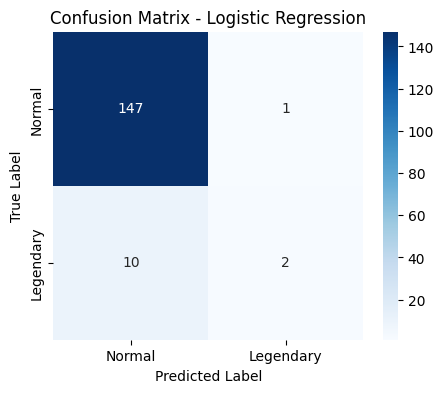

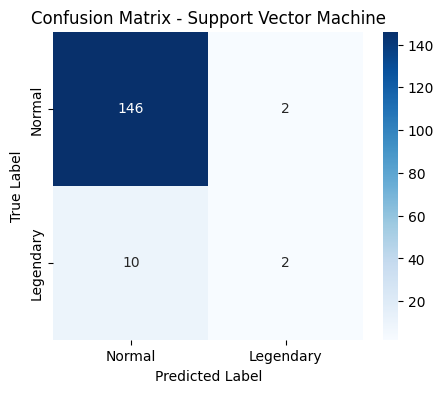

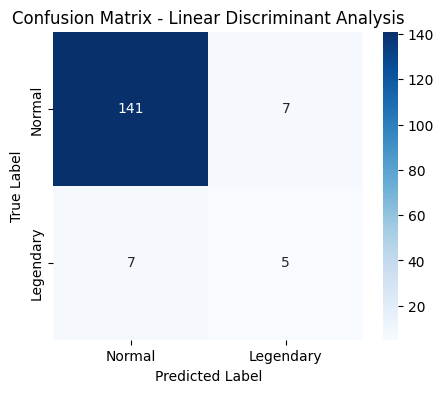

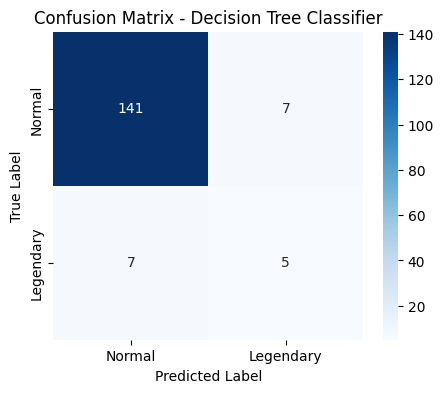

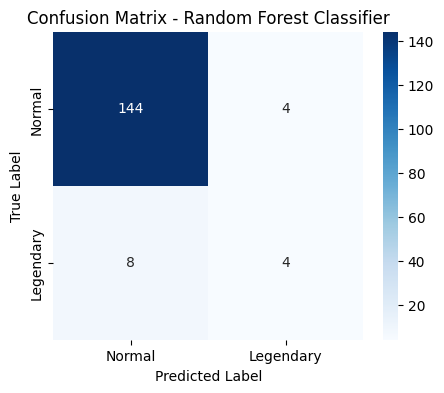

In [15]:
#Logistic Regression
plt.figure(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Legendary'],
            yticklabels=['Normal', 'Legendary'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Support Vector Machine
plt.figure(figsize=(5, 4))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Legendary'],
            yticklabels=['Normal', 'Legendary'])
plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Linear Discriminant Analysis
plt.figure(figsize=(5, 4))
cm_lda = confusion_matrix(y_test, y_pred_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Legendary'],
            yticklabels=['Normal', 'Legendary'])
plt.title('Confusion Matrix - Linear Discriminant Analysis')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Decision Tree
plt.figure(figsize=(5, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Legendary'],
            yticklabels=['Normal', 'Legendary'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Random Forest
plt.figure(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Legendary'],
            yticklabels=['Normal', 'Legendary'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()